# SmartCart: Ecommerce customer segmentation system

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing


### Handle Missing Values

In [4]:
print(df["Income"].isnull().sum())

24


In [5]:
print(df["Income"].dtype)
print(df["Income"].head())

float64
0    58138.0
1    46344.0
2    71613.0
3    26646.0
4    58293.0
Name: Income, dtype: float64


In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
print(df["Income"].isnull().sum())
print(df["Income"].dtype)

0
float64


In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

# Feature Engineering

In [9]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

In [10]:
# Customer_Tenure_Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days # dt.days -> Total no of days

In [11]:
# Total_Spending 
df["Total_Spending"] = df["MntWines"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntFishProducts"] + df["MntGoldProds"]

In [12]:
# Total_Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [13]:
# Education 
df["Education"].value_counts()

# so its has alot of categories and to make it simple for encoding convert it to Post Grad, grad and under grad

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "PhD" : "Postgraduate", "Master" : "Postgraduate"
})

In [14]:
df["Education"].value_counts() #Now only 3 categoris we have

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [15]:
# Marital_Status

df["Marital_Status"].value_counts()
# Too categories convert it to -> Partner and Alone

# New Feature created ie. "living with"

df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner", "Together" : "Partner",
    "Single" : "Alone", "Divorced" : "Alone", "Widow" : "Alone", "Absurd" : "Alone", "YOLO" : "Alone"
})

In [16]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### Drop Unnecessary Columns

In [17]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [18]:
df.head()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [19]:
df_cleaned.shape

(2240, 15)

In [20]:
df.shape

(2240, 27)

In [21]:
df_cleaned.head()
df_cleaned.info()
df_cleaned.isnull().sum()
df_cleaned.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2240 non-null   object 
 1   Income                2240 non-null   float64
 2   Recency               2240 non-null   int64  
 3   NumDealsPurchases     2240 non-null   int64  
 4   NumWebPurchases       2240 non-null   int64  
 5   NumCatalogPurchases   2240 non-null   int64  
 6   NumStorePurchases     2240 non-null   int64  
 7   NumWebVisitsMonth     2240 non-null   int64  
 8   Complain              2240 non-null   int64  
 9   Response              2240 non-null   int64  
 10  Age                   2240 non-null   int64  
 11  Customer_Tenure_Days  2240 non-null   int64  
 12  Total_Spending        2240 non-null   int64  
 13  Total_Children        2240 non-null   int64  
 14  Living_With           2240 non-null   object 
dtypes: float64(1), int64(

(2240, 15)

# Outliers

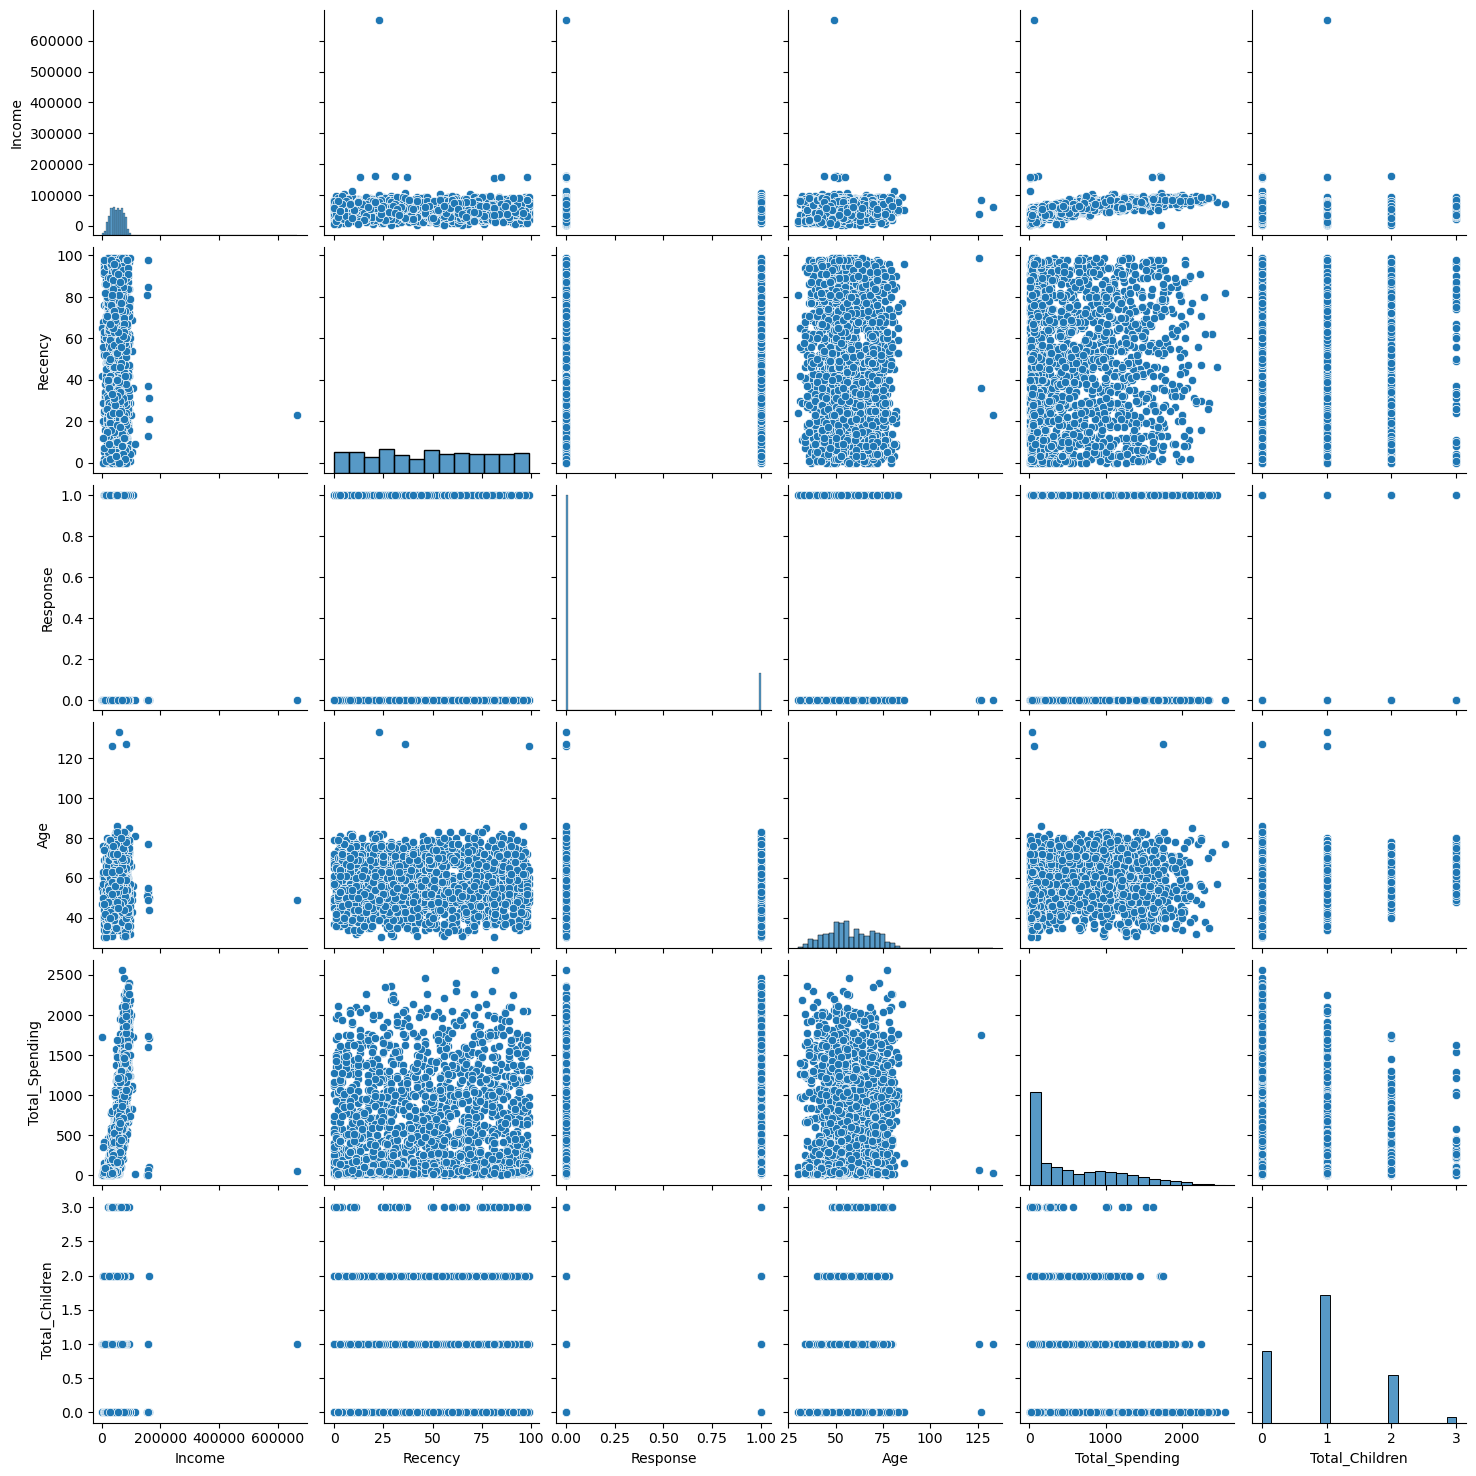

In [22]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [23]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


In [24]:
# 4 Outliers get removed from our dataset

# Heatmap


In [25]:
corr = df_cleaned.corr(numeric_only = True) #Only numerical features are used

In [26]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.782947,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020036,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.061751,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.513170,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.776258,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.669010,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.493481,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.034587,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.264566,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.117541,0.095512


<Axes: >

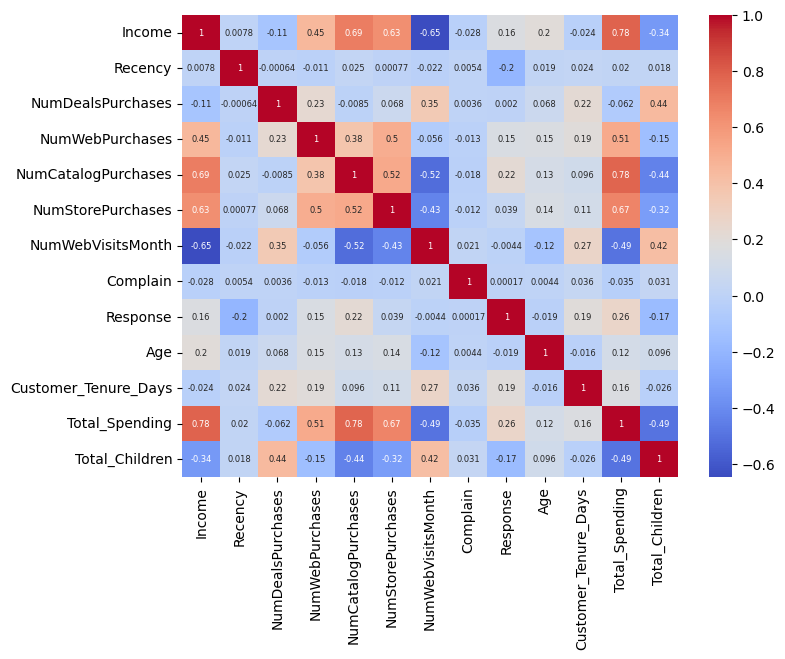

In [27]:
plt.figure(figsize = (8, 6))

sns.heatmap(
    corr, 
    annot = True,
    annot_kws = {"size" : 6},
    cmap = "coolwarm" 
)


# Encoding

In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
df_cleaned.columns
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2236 non-null   object 
 1   Income                2236 non-null   float64
 2   Recency               2236 non-null   int64  
 3   NumDealsPurchases     2236 non-null   int64  
 4   NumWebPurchases       2236 non-null   int64  
 5   NumCatalogPurchases   2236 non-null   int64  
 6   NumStorePurchases     2236 non-null   int64  
 7   NumWebVisitsMonth     2236 non-null   int64  
 8   Complain              2236 non-null   int64  
 9   Response              2236 non-null   int64  
 10  Age                   2236 non-null   int64  
 11  Customer_Tenure_Days  2236 non-null   int64  
 12  Total_Spending        2236 non-null   int64  
 13  Total_Children        2236 non-null   int64  
 14  Living_With           2236 non-null   object 
dtypes: float64(1), int64(12), 

In [30]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

# we get enc_cols now convert it to df

enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

In [31]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [32]:
# Now concat enc_df with df_cleaned by dropping educ and living column

df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df], axis = 1)

In [33]:
df_encoded.head()
df_encoded.shape #No. of columns increased

(2236, 18)

In [93]:
# Before applying scaling store our data 

X = df_encoded

# Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

In [62]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize Data

In [63]:
X_scaled.shape

(2236, 18)

In [64]:
# We can't use 18 Dimensions so use PCA

### PCA : Dimensionality Reduction

In [41]:
# 2D

from sklearn.decomposition import PCA

# pca = PCA(n_components = 2)
# x_pca = pca.fit_transform(X_scaled)

# # Plot
# plt.figure(figsize = (8, 6))

# plt.scatter(
#     x = x_pca[:, 0],
#     y = x_pca[:, 1]
# )

# # Check variance

# pca.explained_variance_ratio_

### array([0.23109378, 0.11385615]) -> 34% varaince it is giving us and ie. majority info is getting lost in this plot

Text(0.5, 0.92, '3D Projections')

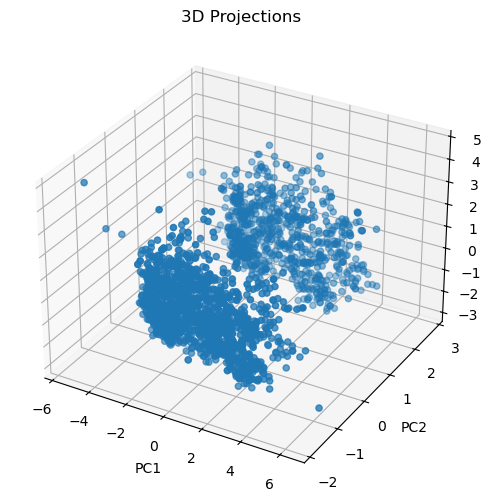

In [42]:
# 3D 
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection = "3d") #111->subgrid
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projections")

# Choose K with elbow mehod and silhoette score

## 1. Elbow Method

In [43]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state =42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [44]:
knee = KneeLocator(range(1, 11), wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.knee
print("Best K =",optimal_k)

Best K = 4


Text(0, 0.5, 'WCSS')

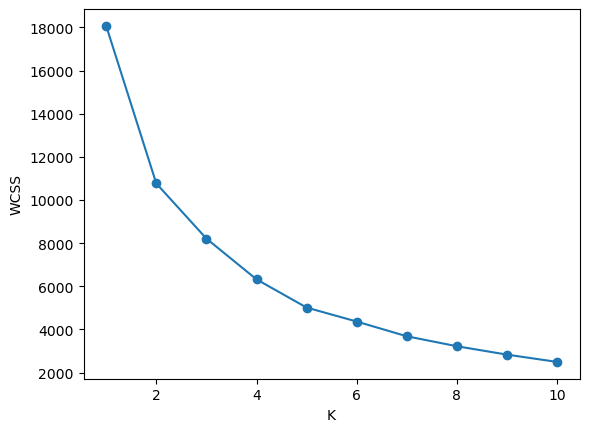

In [45]:
# Plot Elbow curve

plt.plot(range(1, 11), wcss, marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")

### 2. Silhouette Score

Text(0, 0.5, 'ss')

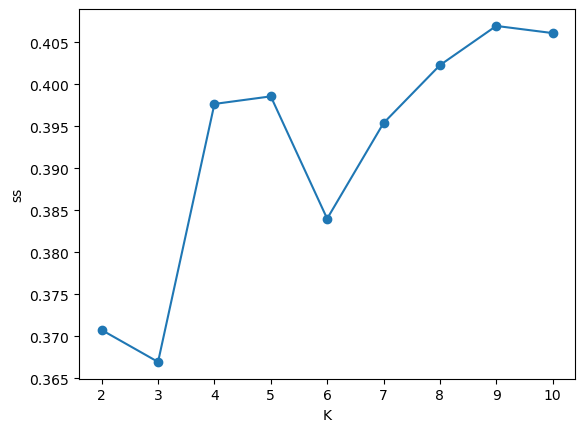

In [46]:
from sklearn.metrics import silhouette_score

ss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    ss.append(score)


# plot
plt.plot(range(2, 11), ss, marker = 'o')
plt.xlabel("K")
plt.ylabel("ss")

# AS ss increases wcss decreases

Text(0, 0.5, 'SS')

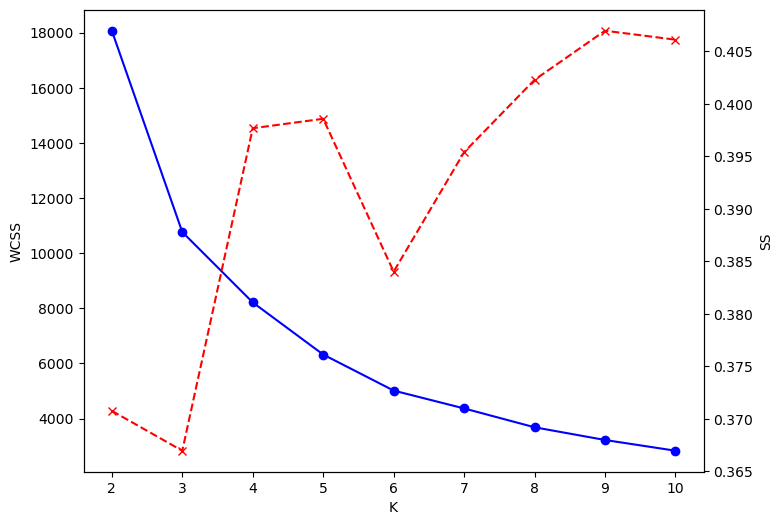

In [47]:
# Combined plot 

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize = (8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker = 'o', color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, ss[:len(k_range)], marker = 'x', color = "red", linestyle = "--")
ax2.set_ylabel("SS")

In [48]:
# Both plots intersect around 4 so K-> 4

# Clustering

## 1. Kmeans

In [49]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 4, random_state =42)
labels_kmeans = kmeans.fit_predict(X_pca)

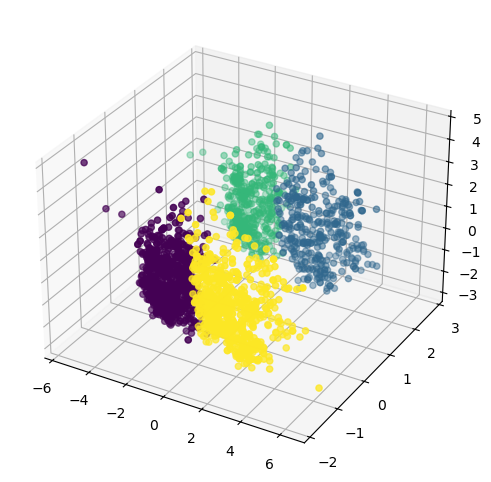

In [50]:
# Visualize 

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:, 0], X_pca[:,1], X_pca[:, 2], c = labels_kmeans)

## 2. Agglomerative Clustering

In [53]:
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)

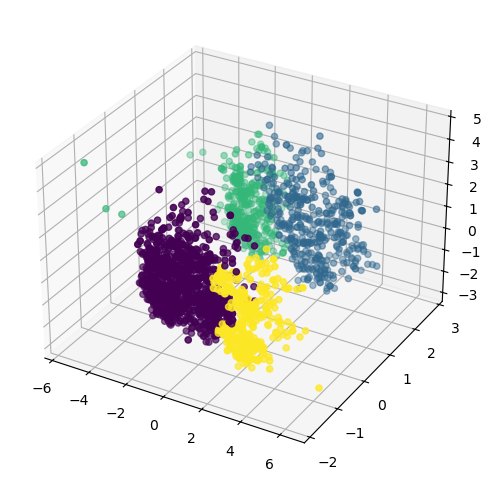

In [54]:
# Visualize 

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels_agg)

In [58]:
from sklearn.metrics import silhouette_score

print(silhouette_score(X_pca, labels_kmeans))
print(silhouette_score(X_pca, labels_agg))

0.3976825418007218
0.3264313279754584


# Characterization of Clusters

In [96]:
# KMeans is selected as bette clustering and high ss score
# X-> encoded data

X["clusters"] = labels_kmeans

In [97]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1613,0,1.0,0.0,0.0,1.0,0.0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,817,0,1.0,0.0,0.0,0.0,1.0,3
3,26646.0,26,2,2,0,4,6,0,0,42,139,56,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,398,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

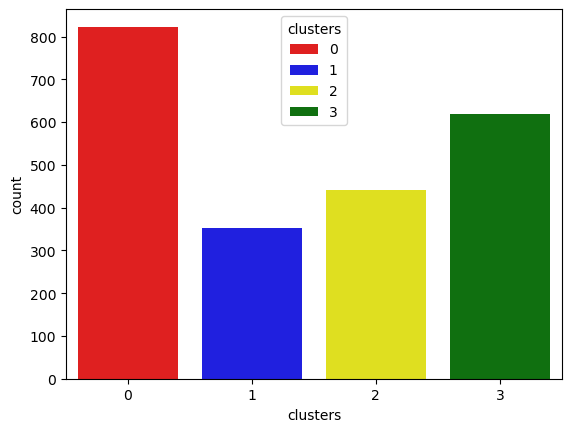

In [98]:
pal  = ["red", "blue", "yellow", "green"]

sns.countplot(x = X["clusters"], palette = pal, hue = X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

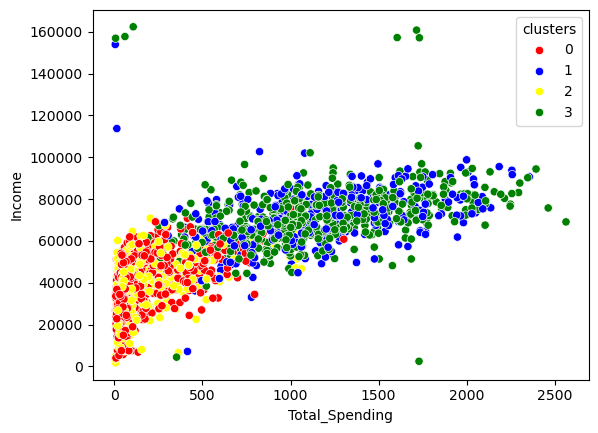

In [99]:
# Income and Total_Spendings pattern

sns.scatterplot(x = X["Total_Spending"], y = X["Income"], hue = X["clusters"], palette = pal) # From Heatmap -> Strong +ve corr 

# Cluster Summary

In [103]:
cluster_summary = X.groupby("clusters").mean() 
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         37450.261847  49.240583           2.540705         2.876063   
1         70701.158640  50.524079           1.872521         5.804533   
2         37191.371882  48.240363           2.562358         2.718821   
3         71059.088045  48.772213           2.130856         5.694669   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.783718           3.756987           6.528554  0.009721   
1                    5.022663           8.436261           3.719547  0.005666   
2                    0.836735           3.641723           6.578231  0.011338   
3                    5.117932           8.534733           3.725363  0.008078   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
clu

In [105]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(ohe, "encoder.pkl")

['encoder.pkl']

In [106]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [117]:
df_cleaned.columns.tolist()

['Education',
 'Income',
 'Recency',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Complain',
 'Response',
 'Age',
 'Customer_Tenure_Days',
 'Total_Spending',
 'Total_Children',
 'Living_With',
 'clusters']

In [118]:
X.columns.tolist()

['Income',
 'Recency',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Complain',
 'Response',
 'Age',
 'Customer_Tenure_Days',
 'Total_Spending',
 'Total_Children',
 'Education_Graduate',
 'Education_Postgraduate',
 'Education_Undergraduate',
 'Living_With_Alone',
 'Living_With_Partner',
 'clusters']

In [119]:
X_model = X.drop(columns=['clusters'])

In [120]:
joblib.dump(X_model.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [121]:
import joblib

X_model = X.drop(columns=['clusters'])

joblib.dump(X_model.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [122]:
import os
print(os.listdir())

['feature_columns.pkl', 'DBSCAN.ipynb', 'Isolation_Forest.ipynb', 'Iris_KMeans.ipynb', 'Hierarchical_Clustering.ipynb', 'LOF.ipynb', 'PCA.ipynb', '.ipynb_checkpoints', 'DBSCAN_for_Anomalies.ipynb', 'kMeans.ipynb', 'thyroid_dataset.csv']


In [123]:
print(ohe.categories_)

[array(['Graduate', 'Postgraduate', 'Undergraduate'], dtype=object), array(['Alone', 'Partner'], dtype=object)]


In [124]:
import os
print(os.getcwd())

/Users/anujanaik/Desktop/ANACONDA/aiml/Unsupervised Learning


In [125]:
os.path.exists("encoder.pkl")
os.path.exists("scaler.pkl")
os.path.exists("pca.pkl")
os.path.exists("kmeans_model.pkl")

False